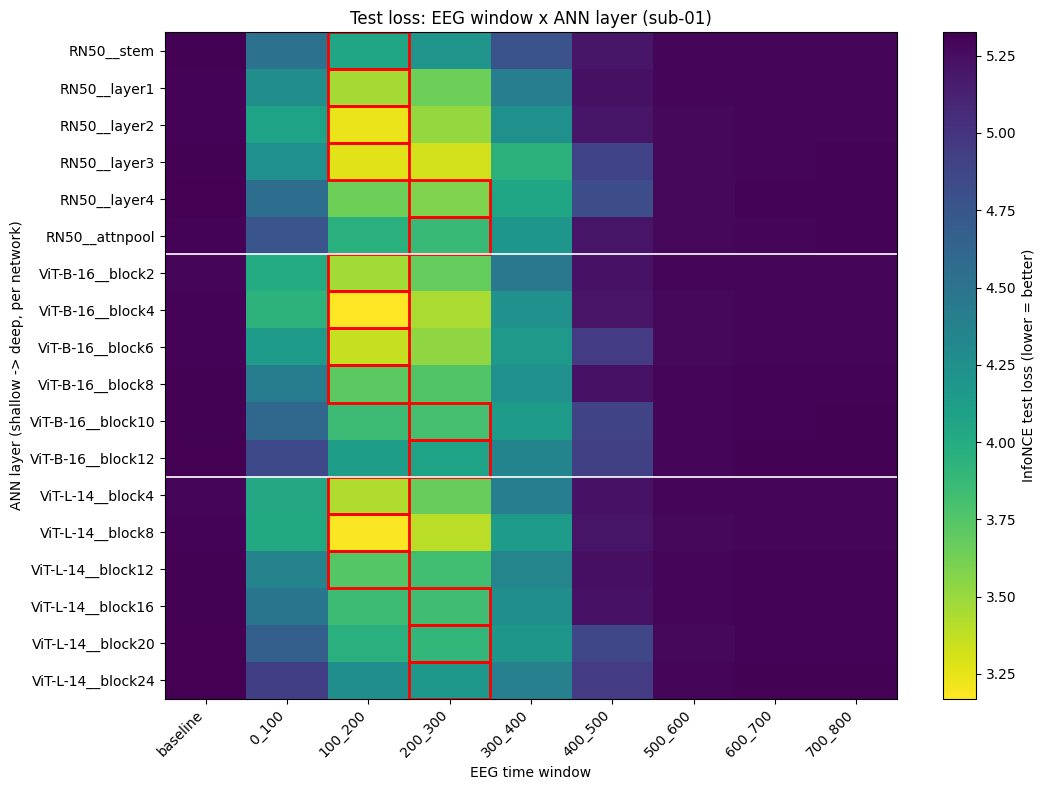

saved -> results/heatmap_sub-01.png


In [4]:
import csv, os
import numpy as np
import matplotlib.pyplot as plt

RES = os.path.expanduser("~/things_eeg/results/alignment_sub-01.csv")

# targets ordered by network, then depth (shallow -> deep)
TARGET_ORDER = [
    "RN50__stem","RN50__layer1","RN50__layer2","RN50__layer3","RN50__layer4","RN50__attnpool",
    "ViT-B-16__block2","ViT-B-16__block4","ViT-B-16__block6","ViT-B-16__block8","ViT-B-16__block10","ViT-B-16__block12",
    "ViT-L-14__block4","ViT-L-14__block8","ViT-L-14__block12","ViT-L-14__block16","ViT-L-14__block20","ViT-L-14__block24",
]
WIN_ORDER = ["baseline","0_100","100_200","200_300","300_400","400_500","500_600","600_700","700_800"]

loss = {}
with open(RES) as f:
    for r in csv.DictReader(f):
        loss[(r["target"], r["window"])] = float(r["test_loss"])

M = np.array([[loss[(t, w)] for w in WIN_ORDER] for t in TARGET_ORDER])  # [18, 9]

fig, ax = plt.subplots(figsize=(11, 8))
im = ax.imshow(M, aspect="auto", cmap="viridis_r")   # _r: low loss = bright = better alignment
ax.set_xticks(range(len(WIN_ORDER))); ax.set_xticklabels(WIN_ORDER, rotation=45, ha="right")
ax.set_yticks(range(len(TARGET_ORDER))); ax.set_yticklabels(TARGET_ORDER)
ax.set_xlabel("EEG time window"); ax.set_ylabel("ANN layer (shallow -> deep, per network)")
ax.set_title("Test loss: EEG window x ANN layer (sub-01)")
plt.colorbar(im, label="InfoNCE test loss (lower = better)")

# red box on the best (lowest-loss) post-stimulus window of each layer -> shows the early->late shift
post = WIN_ORDER[1:]
for i, t in enumerate(TARGET_ORDER):
    j = int(np.argmin([loss[(t, w)] for w in post])) + 1   # +1 skips the baseline column
    ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor="red", lw=2))

for y in (5.5, 11.5):     # separators between the three networks
    ax.axhline(y, color="white", lw=1.2)

plt.tight_layout()
plt.savefig(os.path.expanduser("~/things_eeg/results/heatmap_sub-01.png"), dpi=150)
plt.show()
print("saved -> results/heatmap_sub-01.png")

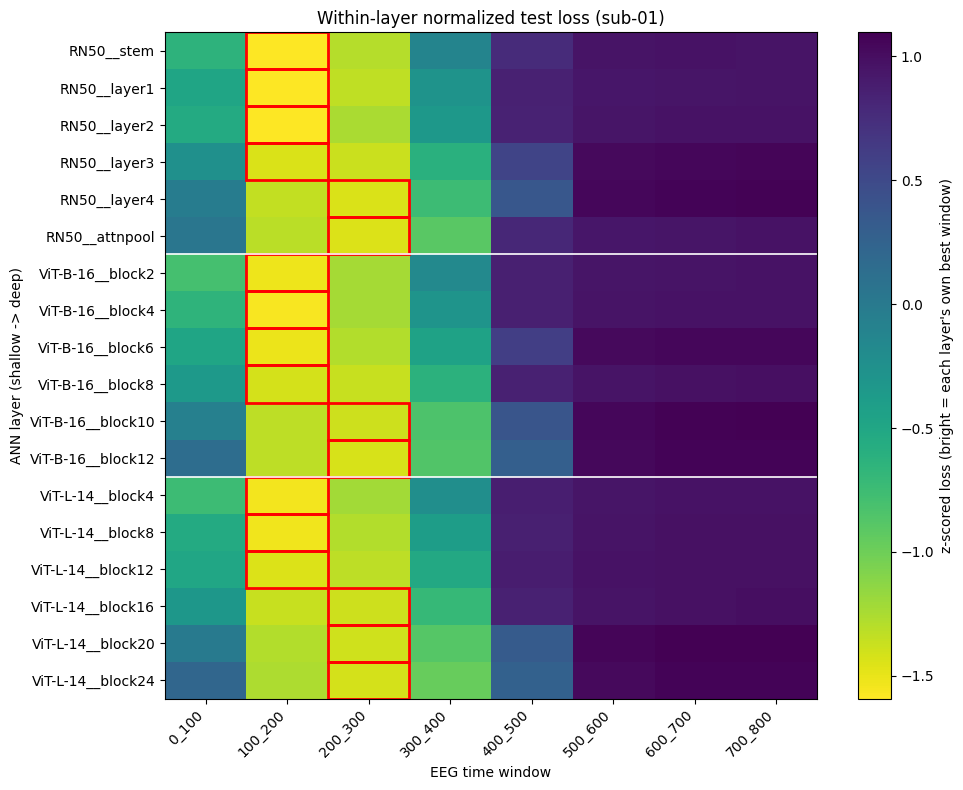

In [5]:
post = WIN_ORDER[1:]  # exclude baseline
P = np.array([[loss[(t, w)] for w in post] for t in TARGET_ORDER])       # [18, 8]
Z = (P - P.mean(1, keepdims=True)) / P.std(1, keepdims=True)             # z-score within each layer

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(Z, aspect="auto", cmap="viridis_r")
ax.set_xticks(range(len(post))); ax.set_xticklabels(post, rotation=45, ha="right")
ax.set_yticks(range(len(TARGET_ORDER))); ax.set_yticklabels(TARGET_ORDER)
ax.set_xlabel("EEG time window"); ax.set_ylabel("ANN layer (shallow -> deep)")
ax.set_title("Within-layer normalized test loss (sub-01)")
plt.colorbar(im, label="z-scored loss (bright = each layer's own best window)")
for i, t in enumerate(TARGET_ORDER):
    j = int(np.argmin([loss[(t, w)] for w in post]))
    ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor="red", lw=2))
for y in (5.5, 11.5): ax.axhline(y, color="white", lw=1.2)
plt.tight_layout(); plt.savefig(os.path.expanduser("~/things_eeg/results/heatmap_norm_sub-01.png"), dpi=150); plt.show()